In [4]:
%pip install ortools

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached protobuf-6.33.6-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached immutabledict-4.3.1-py3-none-any.whl.metadata (3.5 kB)
   ---------------------------------------- 0.0/23.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/23.9 MB ? eta -:--:--
   - -------------------------------------- 1.0/23.9 MB 3.8 MB/s eta 0:00:07
   ---- ----------------------------------- 2.6/23.9 MB 5.4 MB/s eta 0:00:04
   -------- ------------------------------- 5.2/23.9 MB 7.8 MB/s eta 0:00:03
   -------------- ------------------------- 8.9/23.9 MB 10.2 MB/s eta 0:00:02
   ---------------------- ----------------- 13.6/23.9 MB 12.6 MB/s eta 0:00:01
   -------------------------------- ------- 19.1/23.9 MB 14.9 MB/s eta 0:00:01
   ---------------------------------------  23.9/23.9 MB 16.2 MB/s eta 0:00:01
   ---------------------------------------- 23.9/23.9 MB 15.1 MB/s  0:00:01
Using cached protobuf-6.33.


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


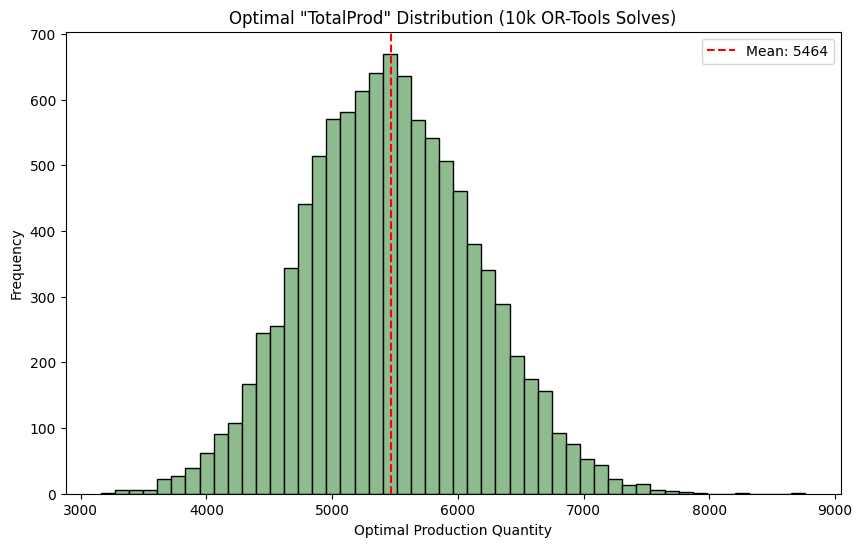

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ortools.linear_solver import pywraplp

# 1. Setup Parameters
n_sim = 10000
p_rain, p_clear = 0.8, 0.2
att_rain_mean, att_clear_mean = 20075.31, 28711.67
std_err = 3744.57
p_purchase = 0.1892
price, royalty = 18.0, 1.02
net_margin = price - royalty # 16.98
cost_t1, cost_t2 = 0.86, 1.06
t1_cap = 5300

# Probability-weighted objective coefficients
coeff_sales_rain = p_rain * net_margin
coeff_sales_clear = p_clear * net_margin

# 2. Generate Random Scenarios
np.random.seed(42)
sampled_att_rain = np.random.normal(att_rain_mean, std_err, n_sim).clip(min=0)
sampled_att_clear = np.random.normal(att_clear_mean, std_err, n_sim).clip(min=0)

# Binomial demand: p=0.1892, n=Sampled Attendance
sampled_demand_rain = np.random.binomial(sampled_att_rain.astype(int), p_purchase)
sampled_demand_clear = np.random.binomial(sampled_att_clear.astype(int), p_purchase)

optimal_productions = []

# 3. Run Simulation with OR-Tools
for i in range(n_sim):
    d_rain = float(sampled_demand_rain[i])
    d_clear = float(sampled_demand_clear[i])
    
    # Initialize Solver (GLOP is the standard linear solver)
    solver = pywraplp.Solver.CreateSolver('GLOP')
    
    # Define Decision Variables
    x1 = solver.NumVar(0, t1_cap, 'Prod_Tier1')
    x2 = solver.NumVar(0, solver.infinity(), 'Prod_Tier2')
    s_rain = solver.NumVar(0, d_rain, 'Sales_Rain')
    s_clear = solver.NumVar(0, d_clear, 'Sales_Clear')
    
    # Constraints: Sales cannot exceed total production
    solver.Add(s_rain <= x1 + x2)
    solver.Add(s_clear <= x1 + x2)
    
    # Objective: Maximize Expected Contribution
    objective = solver.Objective()
    objective.SetCoefficient(s_rain, coeff_sales_rain)
    objective.SetCoefficient(s_clear, coeff_sales_clear)
    objective.SetCoefficient(x1, -cost_t1)
    objective.SetCoefficient(x2, -cost_t2)
    objective.SetMaximization()
    
    # Solve and Store Result
    status = solver.Solve()
    if status == pywraplp.Solver.OPTIMAL:
        optimal_productions.append(x1.solution_value() + x2.solution_value())

# 4. Visualize
plt.figure(figsize=(10, 6))
plt.hist(optimal_productions, bins=50, color='darkseagreen', edgecolor='black')
plt.axvline(np.mean(optimal_productions), color='red', linestyle='--', label=f'Mean: {np.mean(optimal_productions):.0f}')
plt.title('Optimal "TotalProd" Distribution (10k OR-Tools Solves)')
plt.xlabel('Optimal Production Quantity')
plt.ylabel('Frequency')
plt.legend()
plt.show()